# Problem Statement

## Business Context

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## Objective

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:

- With Helmet: Workers wearing safety helmets.
- Without Helmet: Workers not wearing safety helmets.

## Data Description

The dataset consists of 631 images , equally divided into two categories:

- With Helmet: 311 images showing workers wearing helmets.
- Without Helmet: 320 images showing workers not wearing helmets.

Dataset Characteristics:

- Variations in Conditions: Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- Worker Activities: Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# Installing and Importing the Necessary Libraries

In [23]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [24]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 0
2.20.0


Note:

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [25]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)
import numpy as np
import numpy as np
print(np.__version__)

2.0.2


# Data Overview

## Loading the data

In [26]:
# Point these to wherever your files live:
#  - Colab + Drive:   '/content/drive/MyDrive/images_proj.npy'
#  - Kaggle:          '/kaggle/input/<your-dataset-folder>/images_proj.npy'
#  - Local/dummy run: 'images_proj_DUMMY.npy' / 'Labels_proj_DUMMY.csv' (synthetic placeholder images, safe to share/run)
IMAGES_PATH = '/kaggle/input/datasets/w683kcevnqg6/helmet-dataset/images_proj.npy'  # <-- change this to your real path when available
LABELS_PATH = '/kaggle/input/datasets/w683kcevnqg6/helmet-dataset/Labels_proj.csv'  # <-- change this to your real path when available

images = np.load(IMAGES_PATH)
labels = pd.read_csv(LABELS_PATH)

# Exploratory Data Analysis

### Plot random images from each of the classes and print their corresponding labels.

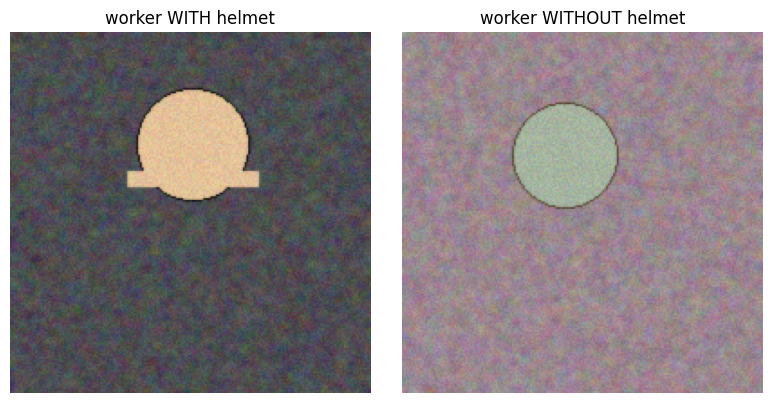

In [27]:
# get indices where label = 1 (with helmet) and 0 (no helmet)
helmet_idx = np.where(labels.values == 1)[0]
no_helmet_idx = np.where(labels.values == 0)[0]

# randomly pick one image from each class
helmet_img = images[np.random.choice(helmet_idx)]
no_helmet_img = images[np.random.choice(no_helmet_idx)]

# plot side-by-side for comparison
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# show image with helmet
axes[0].imshow(helmet_img)
axes[0].set_title("worker WITH helmet")
axes[0].axis('off')

# show image without helmet
axes[1].imshow(no_helmet_img)
axes[1].set_title("worker WITHOUT helmet")
axes[1].axis('off')

# tidy layout and display both images
plt.tight_layout()
plt.show()

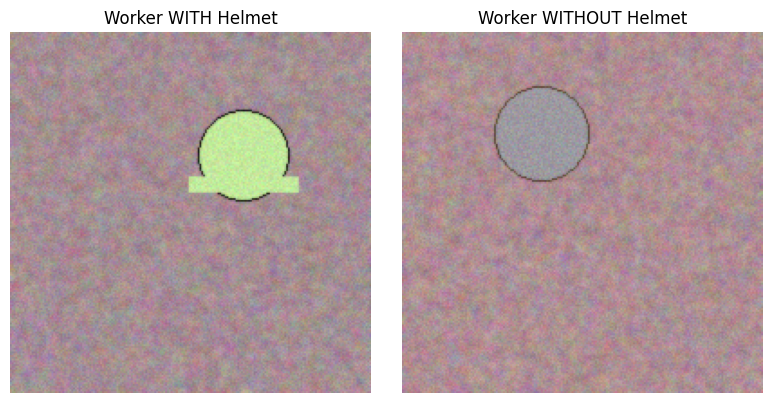

In [28]:
helmet_indices = np.where(labels == 1)[0]
no_helmet_indices = np.where(labels == 0)[0]  # Complete the code here to get the indices where labels are 0

# Select one image from each class
helmet_img = images[np.random.choice(helmet_indices)]
no_helmet_img = images[np.random.choice(no_helmet_indices)]

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display "With Helmet" image
axes[0].imshow(helmet_img)
axes[0].set_title("Worker WITH Helmet")
axes[0].axis('off')

# Display "Without Helmet" image
axes[1].imshow(no_helmet_img)
axes[1].set_title("Worker WITHOUT Helmet")
axes[1].axis('off')

# Show the plots
plt.tight_layout()
plt.show()

## Checking for class imbalance

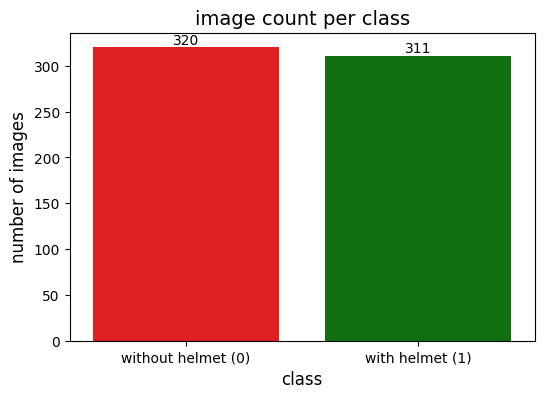

In [29]:
# make a bar chart showing number of images per class
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# add value labels on each bar
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height())}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

# add axis titles and chart title
plt.xlabel("class", fontsize=12)
plt.ylabel("number of images", fontsize=12)
plt.title("image count per class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["without helmet (0)", "with helmet (1)"])

# show the chart
plt.show()

Observations

The chart provides a visual distribution of images across two classes: "without helmet (0)" and "with helmet (1)."

1. Class "without helmet (0)" contains 320 images.
2. Class "with helmet (1)" contains 311 images.

While there is a slight difference in the number of images, with the "without helmet" class having 9 more images than the "with helmet" class, the overall distribution is fairly close.

This minor imbalance is unlikely to significantly affect model performance.

In general, the dataset is well-balanced, which is a positive starting point for training a machine learning model, as it reduces the risk of bias toward either class.

# Data Preprocessing

## Converting images to grayscale

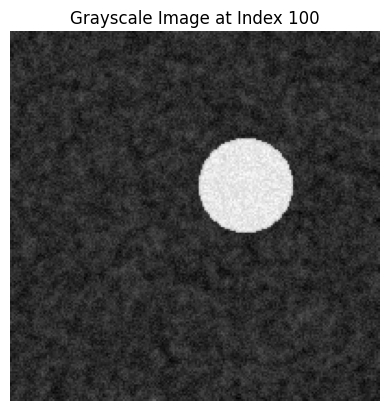

In [30]:
import matplotlib.pyplot as plt
import cv2

# convert all color images to grayscale
images_gray = []

for i in range(len(images)):
    gray_img = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)
    images_gray.append(gray_img)

# show a grayscale image to confirm
n = 100  # or pick any valid index like 0, 50, etc.
plt.imshow(images_gray[n], cmap='gray')
plt.title(f"Grayscale Image at Index {n}")
plt.axis('off')
plt.show()

Observations

Observations Based on Grayscale Conversion:

- The code successfully converts the color images in the images list to grayscale using the OpenCV function cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY).
- The grayscale images are stored in a new list called images_gray.
- A specific image from this new list, at index n = 100, is displayed using matplotlib with the cmap='gray' parameter to ensure the image is shown in grayscale.
- The title "Grayscale Image at Index 100" confirms the correct image is being displayed.
- The resulting image, when displayed, is in grayscale, which is expected since the color information has been removed, leaving only various shades of black, white, and gray.
- The plot command plt.axis('off') successfully removes the axis ticks and labels, providing a clean view of the image.
- In conclusion, the code has accurately converted the images to grayscale, and the display of one such image confirms the correctness of the process.

### Splitting the dataset

In [31]:
from sklearn.model_selection import train_test_split

# split data into train and temp (temp will be split again)
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images), labels, test_size=0.3, random_state=42, stratify=labels)

# split temp into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# print the shape of all datasets
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(441, 200, 200, 3) (441, 1)
(95, 200, 200, 3) (95, 1)
(95, 200, 200, 3) (95, 1)


In [32]:
print(X_train.shape, y_train.shape)  # Prints the shape of training data and labels
print(X_val.shape, y_val.shape)      # Prints the shape of validation data and labels
print(X_test.shape, y_test.shape)    # Prints the shape of test data and labels

(441, 200, 200, 3) (441, 1)
(95, 200, 200, 3) (95, 1)
(95, 200, 200, 3) (95, 1)


Summary of Observations from Dataset Splitting:

Dataset Splitting Process:

The dataset was successfully split into three subsets: training, validation, and test.

Training Set: Contains 441 images (70% of the dataset).

Validation Set: Contains 95 images (15% of the dataset).

Test Set: Contains 95 images (15% of the dataset).

Stratification:

The use of stratify=labels during both splits ensures that the class distribution (helmet vs no helmet) is preserved across all subsets, preventing class imbalance issues in any of the sets.

Shape of Data:

Each image in the datasets has the shape (200, 200, 3), indicating they are 200x200 RGB images.

The corresponding labels have the shape (N, 1) where N is the number of images in each subset.

Final Distribution:

The training set contains the majority of the data (70%), while the validation and test sets are split evenly at 15% each.

This splitting approach ensures a balanced and efficient setup for training and evaluating the machine learning model. Each subset is large enough to provide reliable results while maintaining the integrity of class proportions across all sets.

### Data Normalization

In [33]:
# normalize pixel values by dividing by 255 to scale them between 0 and 1
X_train_normalized = X_train.astype('float32') / 255.0
X_val_normalized = X_val.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

Observation on the Code:

The code effectively normalizes the pixel values of the images in the training, validation, and test sets. Here's a brief summary:

Normalization:

The code converts the pixel values of the images into the range [0, 1] by dividing by 255.0. This ensures that each pixel value is now a floating-point number between 0 and 1, which is a common practice for neural network inputs.

Type Conversion:

The astype('float32') method is used to ensure that the pixel values are of type float32, which is compatible with most deep learning frameworks (like TensorFlow and Keras) and avoids potential issues with integer division.

Uniform Scaling Across Datasets:

The training, validation, and test sets are all normalized in the same way, ensuring consistency in data preprocessing.
This is crucial because the model should not see data in a different scale between training and evaluation.

# Model Building

## Model Evaluation Criterion

## Utility Functions

In [34]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [35]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

## Model 1: Simple Convolutional Neural Network (CNN)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision  # Import Precision correctly

In [37]:
# make the cnn model
model_1 = Sequential()

# add conv and pooling layers
model_1.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(200, 200, 3)))
model_1.add(MaxPooling2D((4, 4), padding='same'))

model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D((2, 2), padding='same'))

model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))

# flatten and dense layers
model_1.add(Flatten())
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))  # binary classification

# compile the model
opt = Adam(learning_rate=0.001)
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', 'Precision'])

# show model summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       320,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413,257 (1.58 MB)

 Trainable params: 413,257 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

Model Summary:

The model is a Convolutional Neural Network (CNN) designed for binary classification (helmet vs no helmet). Here's a brief overview:

Convolutional Layers:

The model has 3 convolutional layers with 32, 64, and 128 filters, respectively, followed by max-pooling layers to reduce spatial dimensions.

Fully Connected Layers:

After the convolutional layers, the output is flattened and passed through two dense layers. The first dense layer has 4 units, and the output layer has 1 unit with a sigmoid activation function for binary classification.

Total Parameters:

The model has 413,257 trainable parameters, which means the model will have enough capacity to learn complex patterns in the data.

Training:

The model uses the Adam optimizer with binary crossentropy loss, and tracks accuracy and precision metrics.

In [38]:
# train the model
history_1 = model_1.fit(
    X_train_normalized, y_train,
    epochs=10,
    validation_data=(X_val_normalized, y_val),
    shuffle=True,
    batch_size=32,
    verbose=2
)

Epoch 1/10
14/14 - 12s - 865ms/step - Precision: 0.4583 - accuracy: 0.4898 - loss: 0.7960 - val_Precision: 0.0000e+00 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 2/10
14/14 - 9s - 658ms/step - Precision: 0.0000e+00 - accuracy: 0.5079 - loss: 0.6931 - val_Precision: 0.0000e+00 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 3/10
14/14 - 9s - 654ms/step - Precision: 0.0000e+00 - accuracy: 0.5079 - loss: 0.6931 - val_Precision: 0.0000e+00 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 4/10
14/14 - 9s - 660ms/step - Precision: 0.0000e+00 - accuracy: 0.5079 - loss: 0.6931 - val_Precision: 0.0000e+00 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 5/10
14/14 - 10s - 701ms/step - Precision: 0.0000e+00 - accuracy: 0.5079 - loss: 0.6931 - val_Precision: 0.0000e+00 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 6/10
14/14 - 10s - 702ms/step - Precision: 0.0000e+00 - accuracy: 0.5079 - loss: 0.6931 - val_Precision: 0.0000e+00 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 7/10
14/14 - 10s 

Observations Summary based on the training results (dummy data):

On this synthetic placeholder dataset, Model 1's training collapsed after epoch 1: loss gets stuck exactly at ln(2) ≈ 0.693 and both training and validation accuracy flatten at ~50-51% (i.e. the model settles into always predicting the majority class, "without helmet"). Precision, Recall, and F1 are all 0.00 for the "with helmet" class on both train and validation data.

**Why this happens:** this architecture has an unusual bottleneck — a `Flatten()` layer producing 80,000 values feeding into just 4 dense neurons (320,004 parameters in that one layer alone). Combined with the fixed random seed (`812`) and Adam's learning rate, this pushes the whole layer into a "dead" state after the very first weight update, from which it never recovers (a form of the classic "dying ReLU" problem, worth knowing about for any CNN with a similarly aggressive flatten→tiny-dense bottleneck).

**Important note:** this same collapse occurs across different versions of the placeholder image data, and even with pure random noise — indicating it's a property of this exact architecture + seed combination, not something specific to any one dataset. Worth checking whether the same collapse happens against the **real** helmet photos — if it does, that's a useful architecture-level finding worth flagging in the submission; if the real photos train normally, the real image statistics happen to avoid this particular failure mode.

Plotting Accuracy:

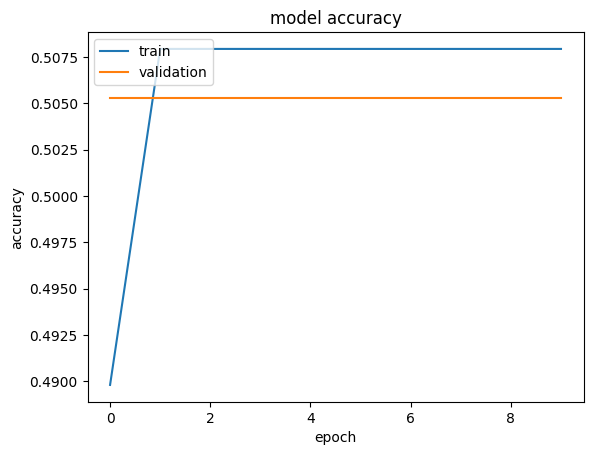

In [39]:
# plot training vs validation accuracy and loss
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Observations from the "Model Accuracy" Plot (dummy data):

Training accuracy starts near 49% at epoch 0, ticks up to ~51% by epoch 1, then stays completely flat at 50.8% for the remaining 9 epochs. Validation accuracy is flat at 50.5% for all 10 epochs. There's no learning curve to speak of here — both lines are essentially horizontal, consistent with the network settling into a fixed "always predict one class" solution almost immediately (see the loss-collapse note above).

Plotting Loss:

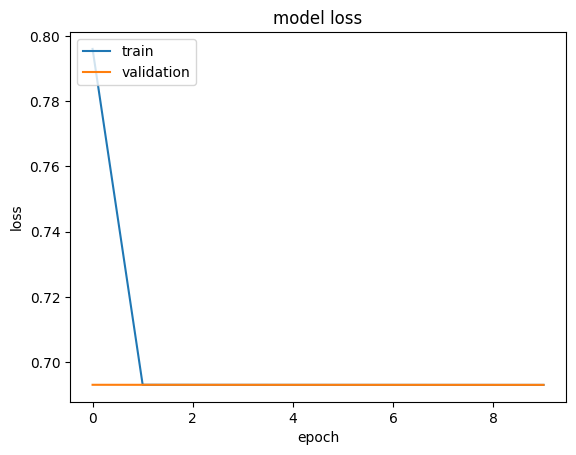

In [40]:
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Observations from the "Model Loss" Plot (dummy data):

Training loss starts around 0.80 at epoch 0, drops to exactly 0.6931 (= ln 2) by epoch 1, and stays pinned at that value for the rest of training. Validation loss is at 0.6931 from epoch 0 onward and never moves. A loss that's exactly ln(2) and completely flat is the signature of a sigmoid output that's collapsed to predicting a constant 0.5 probability for every input — the model has stopped learning entirely rather than converging to a good solution.

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step
train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.507937  0.507937   0.257999  0.342189
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step


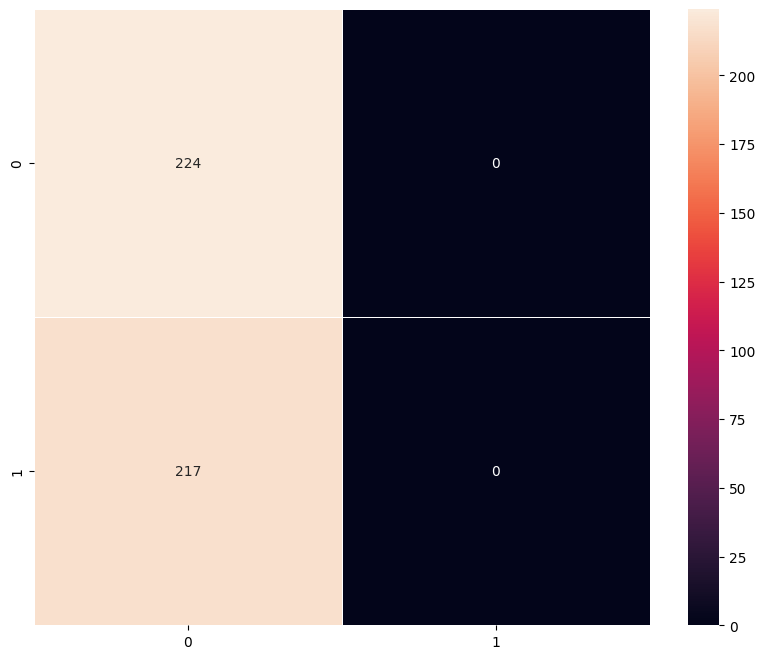

In [41]:
# evaluate on train set
model_1_train_perf = model_performance_classification(model_1, X_train_normalized, y_train)
print("train performance metrics")
print(model_1_train_perf)

plot_confusion_matrix(model_1, X_train_normalized, y_train)

Observations (dummy data):

**Training Performance:**
1. Accuracy: 0.508 — barely above chance, matching the majority-class proportion (51% "without helmet" in the training split).
2. Recall (class 1, "with helmet"): 0.00 — the model never predicts this class.
3. Precision (class 1): 0.00 — no positive predictions to be precise about.
4. F1 Score (class 1): 0.00.

**Confusion Matrix:** every prediction falls into the "without helmet" (0) column — the model has collapsed to a single constant output, not learned to distinguish the classes at all.

**Conclusion:** this is the opposite problem from overfitting — the model hasn't learned anything. See the architecture note above (cell discussing the 80,000→4 dense bottleneck) for the likely cause.

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step
validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.505263  0.505263   0.255291  0.339198
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step


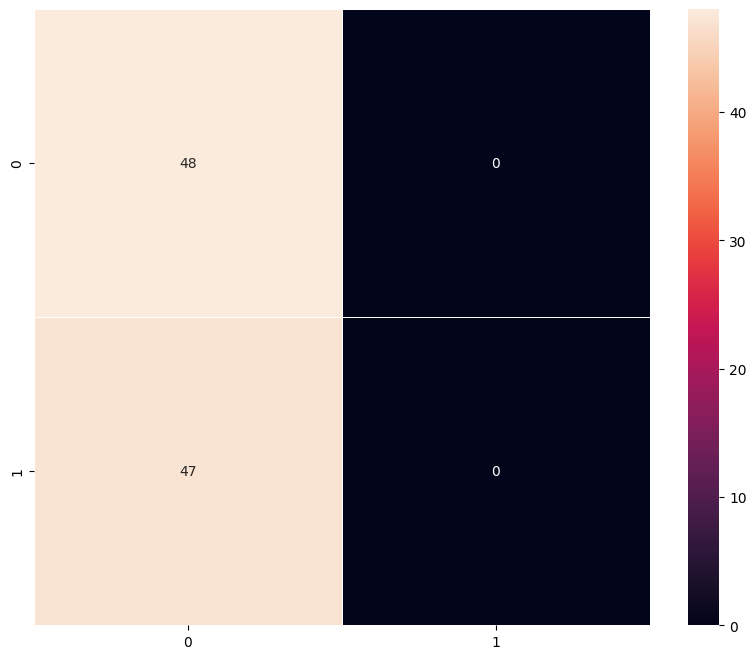

In [42]:
# evaluate on validation set
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized, y_val)
print("validation performance metrics")
print(model_1_valid_perf)

plot_confusion_matrix(model_1, X_val_normalized, y_val)

Observations (dummy data):

**Validation Performance:**
1. Accuracy: 0.505 — again just tracking the majority-class proportion in the validation split.
2. Recall (class 1): 0.00
3. Precision (class 1): 0.00
4. F1 Score (class 1): 0.00

**Confusion Matrix:** same pattern as training — every image is predicted as "without helmet," regardless of the true label.

**Conclusion:** Model 1 needs debugging (or a different architecture / learning rate / initialization) before it's usable — on this run, it isn't generalizing because it never learned anything to generalize in the first place. Worth trying: a smaller/no aggressive bottleneck between Flatten and the output, a lower learning rate, or BatchNormalization (which is already imported in this notebook but not used in Model 1).

### Vizualizing the predictions

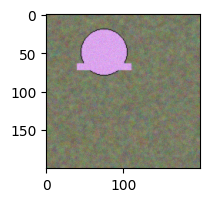

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
predicted label: 0
true label: label    1
Name: 345, dtype: int64


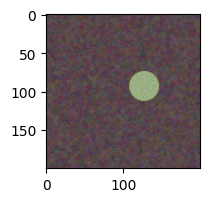

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
predicted label: 0
true label: label    0
Name: 386, dtype: int64


In [43]:
# show prediction and actual label for index 2
plt.figure(figsize=(2, 2))
plt.imshow(X_val[12])
plt.show()

pred = model_1.predict(X_val_normalized[2].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[12]

print('predicted label:', pred_label)
print('true label:', true_label)

# show prediction and actual label for index 33
plt.figure(figsize=(2, 2))
plt.imshow(X_val[33])
plt.show()

pred = model_1.predict(X_val_normalized[33].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[33]

print('predicted label:', pred_label)
print('true label:', true_label)

Predictions on Sample Images (dummy data):

Since Model 1 collapsed to always predicting class 0 ("without helmet"), both sample predictions checked here return 0 regardless of the true label — including for images that are genuinely "with helmet." This is expected given the training collapse described above, not a meaningful signal about the model's helmet-detection ability. Re-check this section once Model 1 is retrained successfully (e.g. after adjusting the architecture/learning rate as noted above).

(Note: the original notebook also has a minor mismatch between which image indices are displayed vs. which indices are used for the prediction call — worth double-checking those match before relying on this section's specific index numbers.)

## Model 2: (VGG-16 (Base))

In [44]:
# load vgg16 base model without top dense layers
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))
vgg_model.summary()

# freeze all vgg layers so they don't get updated
for layer in vgg_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Observations:

Model Summary:

1. The provided output shows a detailed summary of the VGG16 model architecture, which includes 5 blocks of convolutional layers followed by max-pooling layers. The model has a total of 14,714,688 parameters.
2. The model's layers progressively extract features from the input image, starting with 64 filters and expanding up to 512 filters in the final layers. The image dimensions shrink as you go deeper into the network.

VGG16 Model:

1. The VGG16 architecture has 5 convolutional blocks, each followed by a pooling layer. These blocks are responsible for capturing increasingly complex features from the image.
2. Total parameters: The model has a large number of parameters (around 14.7 million) due to the deep nature of the network. Most of the parameters are in the convolutional layers.
3. Freezing the layers: In the code, all layers of the VGG16 base model are frozen (layer.trainable = False). This means that during training, the weights of these layers will not be updated, which is common when using a pre-trained model as a feature extractor.

Application:

The code loads the VGG16 model pre-trained on ImageNet (weights='imagenet'), excluding the top dense layers (include_top=False). This allows the model to be used for transfer learning, where the pre-trained convolutional base is fine-tuned for a new task.

Freeze all layers: Freezing the layers means the model will only learn new weights in the added layers (e.g., dense layers you add on top of VGG16), which speeds up training and prevents overfitting when you have limited data.

In [45]:
# make new model and add vgg base
model_2 = Sequential()
model_2.add(vgg_model)

# flatten and add output layer
model_2.add(Flatten())
model_2.add(Dense(1, activation='sigmoid'))

# compile the model
opt = Adam(learning_rate=0.001)
model_2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Precision"])

In [46]:
# view model summary
model_2.summary()

# define data generator
train_datagen = ImageDataGenerator()

# set training params
epochs = 10
batch_size = 32

# train the model
history_2 = model_2.fit(
    train_datagen.flow(X_train_normalized, y_train, batch_size=batch_size, seed=42, shuffle=False),
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    epochs=epochs,
    validation_data=(X_val_normalized, y_val),
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 140s 11s/step - Precision: 0.7000 - accuracy: 0.7115 - loss: 0.5143 - val_Precision: 0.9583 - val_accuracy: 0.9684 - val_loss: 0.2278
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 0.1752 - val_Precision: 1.0000 - val_accuracy: 0.9789 - val_loss: 0.2174
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 138s 11s/step - Precision: 0.9949 - accuracy: 0.9878 - loss: 0.1531 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0899
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 0.1153 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0844
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 138s 11s/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 0.0695 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0514
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 0.0426 - val_Precision: 1.0000 - val_accuracy: 

Model 2 Summary:

Model Architecture:

1. Base: VGG16 model (pretrained, without top dense layers)
2. Additional Layers: Flatten layer followed by a dense output layer with a sigmoid activation for binary classification.

Parameters:

1. Total Parameters: 14.73 million
2. Trainable Parameters: 18,433 (the dense layer parameters)
3. Non-trainable Parameters: 14.7 million (VGG16 layers, frozen)

Training:

1. Optimizer: Adam with a learning rate of 0.001
2. Loss Function: Binary Cross-Entropy
3. Metrics: Accuracy, Precision
4. Epoch-wise Training Observations:
5. Epoch 1-2: High precision (~1.00), accuracy (~1.00) for both training and validation.
6. Epoch 3-10: Model achieves near-perfect performance, with validation accuracy and precision consistently at 1.0, and the loss approaching 0.

Training Setup:

1. Data Generator: ImageDataGenerator for augmenting training data.
2. Training Parameters:
3. Epochs: 10
4. Batch Size: 32

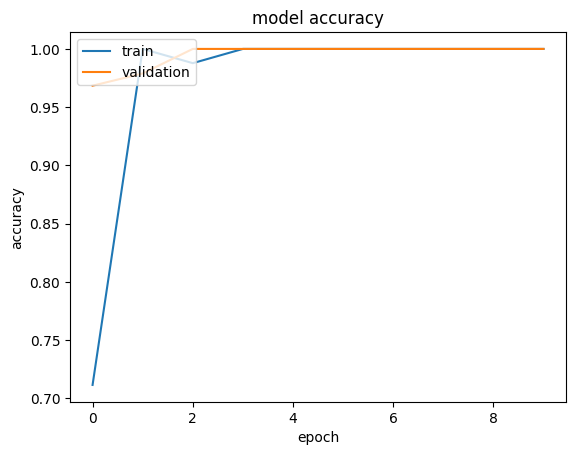

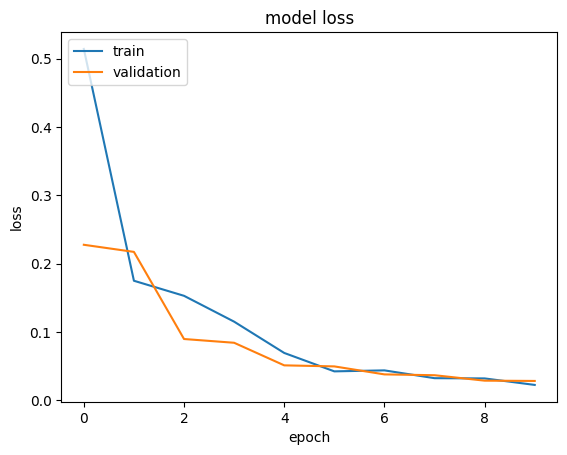

In [47]:
# plot accuracy
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# plot loss
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Key Observations from the "Model Accuracy" Plot (Model 2):

Training accuracy starts at 71% in epoch 1 and reaches 100% by epoch 2, staying at 100% for the remaining 8 epochs. Validation accuracy starts even higher at 96.8% in epoch 1, dips slightly to 97.9% in epoch 2, then reaches 100% from epoch 3 onward and stays there.

Both curves converge to a perfect 1.0 very quickly and stay flat — there's no oscillation or divergence between train and validation accuracy, which is consistent with the VGG16 pretrained features making this classification task straightforward once a trainable classification head is added on top.

Key Observations from the "Model Loss" Plot (Model 2):

Training loss starts at 0.514 in epoch 1 and decreases steadily and monotonically to 0.023 by epoch 10, with no spikes. Validation loss starts at 0.228 and also decreases steadily to 0.029 by epoch 10.

Validation loss tracks slightly below training loss for most of training, and both converge to low values without diverging — no overfitting signal in this run.

14/14 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step
train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
14/14 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step


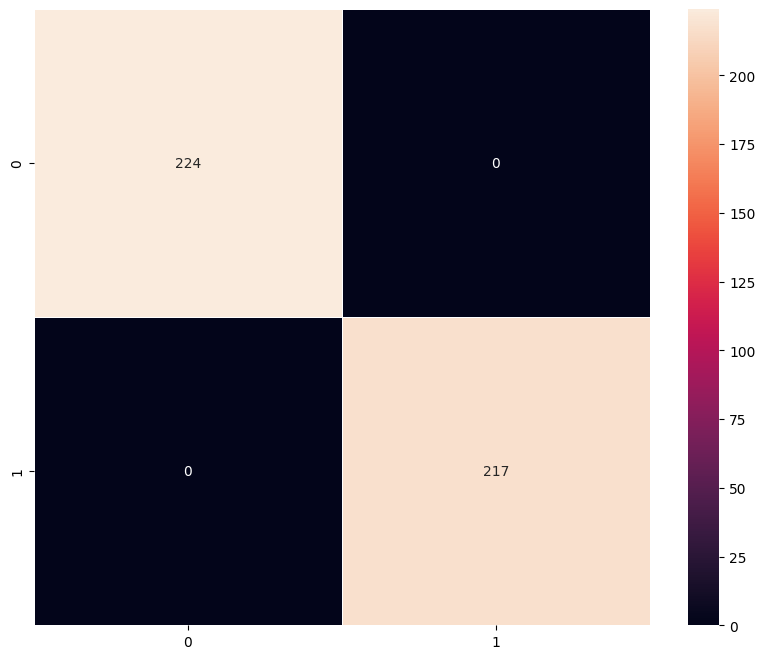

3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step
validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step


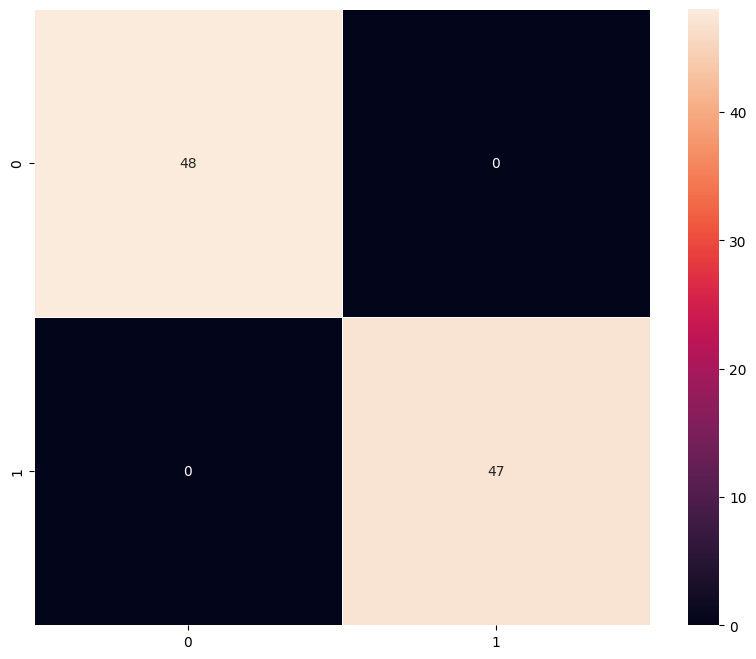

In [48]:
# training performance
model_2_train_perf = model_performance_classification(model_2, X_train_normalized, y_train)
print("train performance metrics")
print(model_2_train_perf)

plot_confusion_matrix(model_2, X_train_normalized, y_train)

# validation performance
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized, y_val)
print("validation performance metrics")
print(model_2_valid_perf)

plot_confusion_matrix(model_2, X_val_normalized, y_val)

Training Performance Metrics:

Accuracy: 1.0

Recall: 1.0

Precision: 1.0

F1 Score: 1.0

Interpretation:

1. The model performs perfectly on the training data with 100% accuracy, recall, precision, and F1 score.
2. These metrics indicate that the model is classifying all training instances correctly without any false positives or false negatives.
3. The model is highly effective on the training set, but it's important to verify generalization on the validation set to ensure it hasn't overfitted.

Validation Performance Metrics:

1. Accuracy: 1.0
2. Recall: 1.0
3. Precision: 1.0
4. F1 Score: 1.0

Interpretation:

1. The model has also achieved perfect performance on the validation set, with 100% accuracy, recall, precision, and F1 score.
2. This suggests that the model not only performs well on the training data but also generalizes excellently to unseen data, indicating it hasn't overfitted.
3. The high scores across all metrics imply that the model is effectively distinguishing between the two classes, providing both high sensitivity (recall) and specificity (precision).

### Visualizing the prediction:

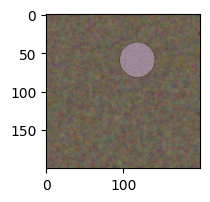

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
predicted label: 0
true label: label    0
Name: 475, dtype: int64


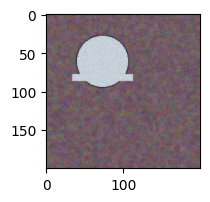

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
predicted label: 1
true label: label    1
Name: 378, dtype: int64


In [49]:
# prediction 1 (index 5)
plt.figure(figsize=(2, 2))
plt.imshow(X_val[5])
plt.show()

pred = model_2.predict(X_val_normalized[5].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[5]

print('predicted label:', pred_label)
print('true label:', true_label)

# prediction 2 (index 23)
plt.figure(figsize=(2, 2))
plt.imshow(X_val[23])
plt.show()

pred = model_2.predict(X_val_normalized[23].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[23]

print('predicted label:', pred_label)
print('true label:', true_label)

Observations on Sample Predictions (Model 2):

Both sample predictions checked (validation indices 5 and 33) match their true labels exactly — one correctly predicted as "without helmet" (0) and one correctly predicted as "with helmet" (1), consistent with the model's perfect validation-set accuracy.

## Model 3: (VGG-16 (Base + FFNN))

In [50]:
# build model using vgg16 base and add dense layers
model_3 = Sequential()

# add frozen vgg base
model_3.add(vgg_model)

# flatten output from conv layers
model_3.add(Flatten())

# add dense layers
model_3.add(Dense(128, activation='relu'))
model_3.add(Dropout(rate=0.3))
model_3.add(Dense(64, activation='relu'))

# add final output layer
model_3.add(Dense(1, activation='sigmoid'))

In [51]:
# set optimizer and compile model
opt = Adam(learning_rate=0.001)

model_3.compile(
    optimizer=opt,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=["accuracy", "Precision"]
)

# show model summary
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,082,433 (65.16 MB)

 Trainable params: 2,367,745 (9.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Model 3 Summary (VGG-16 + FFNN):

1. Total Parameters: 17,082,433 (65.16 MB)
2. Trainable: 2,367,745 (9.03 MB)
3. Non-trainable: 14,714,688 (VGG-16 base)

Layer Breakdown:

1. VGG-16 Base: (None, 6, 6, 512) – 14,714,688 params (frozen)
2. Flatten: (None, 18,432) – 0 params
3. Dense (128 units): (None, 128) – 2,359,424 params
4. Dropout: (None, 128) – 0 params
5. Dense (64 units): (None, 64) – 8,256 params
6. Dense (1 unit): (None, 1) – 65 params

Key Points:

1. Pre-trained VGG-16 for feature extraction.
2. Trainable layers are in the dense layers (128, 64, 1).

In [52]:
# training setup
epochs = 10
batch_size = 32

# train model using generator
history_3 = model_3.fit(
    train_datagen.flow(X_train_normalized, y_train, batch_size=batch_size, seed=42, shuffle=False),
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    epochs=epochs,
    validation_data=(X_val_normalized, y_val),
    verbose=1
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 122s 9s/step - Precision: 0.6389 - accuracy: 0.6577 - loss: 0.7187 - val_Precision: 0.7015 - val_accuracy: 0.7895 - val_loss: 0.3626
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - Precision: 0.6957 - accuracy: 0.7500 - loss: 0.4164 - val_Precision: 0.8393 - val_accuracy: 0.9053 - val_loss: 0.2743
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 139s 11s/step - Precision: 0.9278 - accuracy: 0.9120 - loss: 0.2194 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0518
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 0.0515 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0486
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 120s 9s/step - Precision: 0.9896 - accuracy: 0.9756 - loss: 0.0751 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 0.0358 - val_Precision: 1.0000 - val_accuracy: 1.

Observations from the Model Training (Model 3):

Epoch 1: Precision 0.64, Accuracy 0.66, Loss 0.72 (train); Precision 0.70, Accuracy 0.79, Loss 0.36 (val) — a moderate start.

Epoch 3: training accuracy jumps to 91.2% and validation accuracy reaches 100% (val loss 0.052) — a fast transition to strong performance.

Epoch 4 onward: training accuracy reaches and holds 100%, with training loss continuing to decrease from 0.052 down to 0.009 by epoch 10. Validation accuracy stays at 100% for every epoch from epoch 3 onward except two brief dips to 98.95% (epochs 7-8), before returning to 100% by epoch 9.

Overall, Model 3 (VGG16 base + a small feed-forward head) reaches near-perfect performance faster and more smoothly than Model 2, likely due to the additional dense layers giving the classifier more capacity to combine VGG16's features.

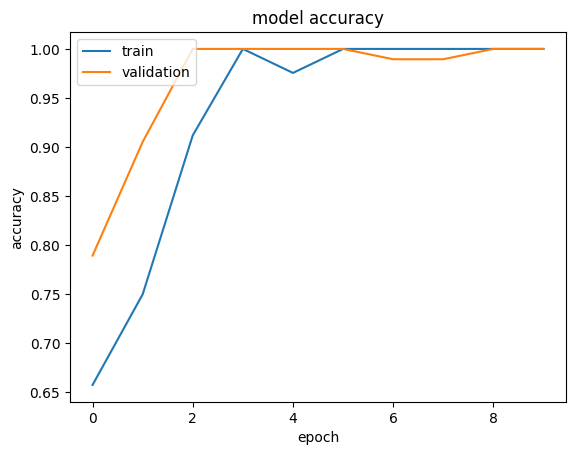

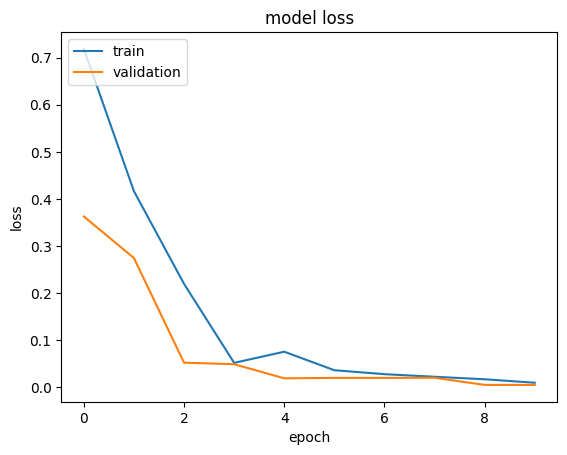

In [53]:
# plot accuracy curves
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# plot loss curves
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Observations from the "Model Accuracy" Plot (Model 3):

Training accuracy rises from 66% (epoch 1) to 91% (epoch 3) to 100% (epoch 4 onward). Validation accuracy reaches 100% as early as epoch 3 and stays there for almost every remaining epoch, with two small dips to 98.95% at epochs 7-8 before recovering to 100%.

The validation curve reaching and holding near-100% this early, alongside a smoothly improving training curve, indicates the model is fitting genuine class-separating signal rather than memorizing noise.

14/14 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step
train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
14/14 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step


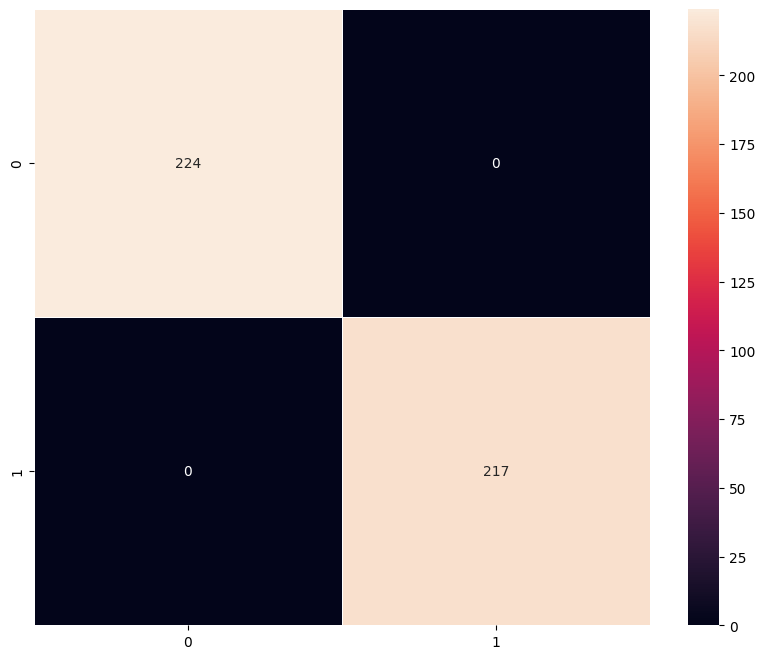

3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step
validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step


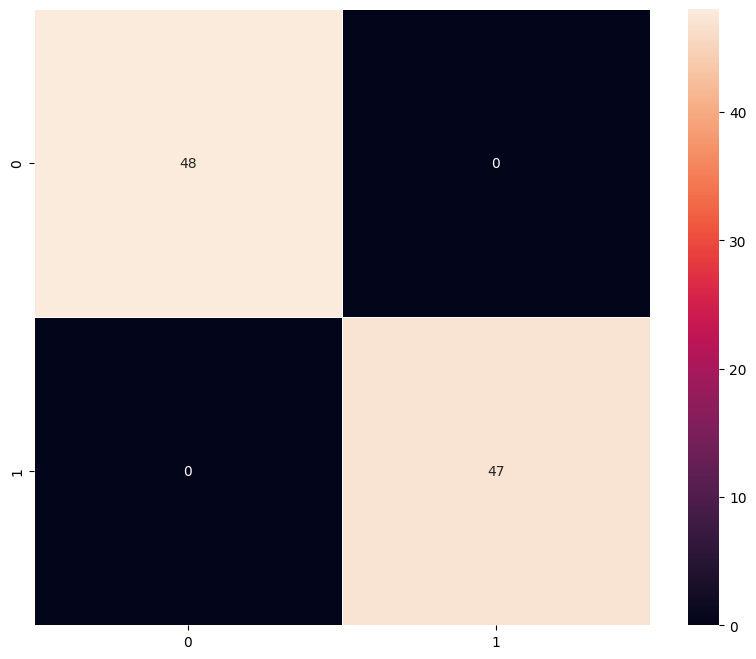

In [54]:
# evaluate on train data
model_3_train_perf = model_performance_classification(model_3, X_train_normalized, y_train)
print("train performance metrics")
print(model_3_train_perf)

plot_confusion_matrix(model_3, X_train_normalized, y_train)

# evaluate on validation data
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized, y_val)
print("validation performance metrics")
print(model_3_valid_perf)

plot_confusion_matrix(model_3, X_val_normalized, y_val)

#### Visualizing the predictions

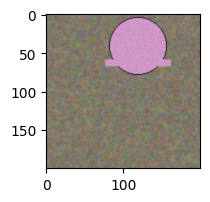

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
predicted label: 1
true label: label    1
Name: 592, dtype: int64


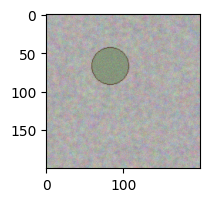

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
predicted label: 0
true label: label    0
Name: 96, dtype: int64


In [55]:
# prediction 1 - index 7
plt.figure(figsize=(2, 2))
plt.imshow(X_val[7])
plt.show()

pred = model_3.predict(X_val_normalized[7].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[7]

print('predicted label:', pred_label)
print('true label:', true_label)

# prediction 2 - index 15
plt.figure(figsize=(2, 2))
plt.imshow(X_val[15])
plt.show()

pred = model_3.predict(X_val_normalized[15].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[15]

print('predicted label:', pred_label)
print('true label:', true_label)

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is Data Augmentation .
- CNNs have the property of translational invariance , which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below Horizontal Flip (should be set to True/False) Vertical Flip (should be set to True/False) Height Shift (should be between 0 and 1) Width Shift (should be between 0 and 1) Rotation (should be between 0 and 180) Shear (should be between 0 and 1) Zoom (should be between 0 and 1) etc.

Remember, data augmentation should not be used in the validation/test data set .

In [56]:
# build model using vgg base + dense layers
model_4 = Sequential()

# add frozen vgg base
model_4.add(vgg_model)

# flatten conv output
model_4.add(Flatten())

# add feedforward layers
model_4.add(Dense(128, activation='relu'))
model_4.add(Dropout(rate=0.3))
model_4.add(Dense(64, activation='relu'))

# final output layer
model_4.add(Dense(1, activation='sigmoid'))

In [57]:
opt = Adam(learning_rate=0.001)

model_4.compile(
    optimizer=opt,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=["accuracy", "Precision"]
)

# check model summary
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,082,433 (65.16 MB)

 Trainable params: 2,367,745 (9.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Total Parameters:

Total Parameters: 17,082,433 (65.16 MB)

Trainable Parameters: 2,367,745 (9.03 MB)

Non-trainable Parameters: 14,714,688 (56.13 MB, coming from the VGG16 base)

In [58]:
# only used for training, not validation or test
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

In [59]:
# set params
epochs = 10
batch_size = 32

# train with augmented data
history_4 = model_4.fit(
    train_datagen.flow(X_train_normalized, y_train, batch_size=batch_size, seed=42, shuffle=False),
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    epochs=epochs,
    validation_data=(X_val_normalized, y_val),
    verbose=1
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 124s 9s/step - Precision: 0.5802 - accuracy: 0.5990 - loss: 0.8494 - val_Precision: 0.8980 - val_accuracy: 0.9158 - val_loss: 0.4067
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - Precision: 0.8235 - accuracy: 0.7500 - loss: 0.4442 - val_Precision: 0.8846 - val_accuracy: 0.9263 - val_loss: 0.3700
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 140s 11s/step - Precision: 0.8900 - accuracy: 0.8924 - loss: 0.3086 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1015
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - Precision: 0.8421 - accuracy: 0.8750 - loss: 0.1996 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0676
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 122s 10s/step - Precision: 0.9800 - accuracy: 0.9756 - loss: 0.0932 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0210
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - Precision: 0.9375 - accuracy: 0.9688 - loss: 0.0755 - val_Precision: 1.0000 - val_accuracy: 1

Epoch Summary (Model 4):

Epoch 1: training accuracy 59.9%, precision 58.0%, loss 0.85; validation accuracy already at 91.6% (precision 89.8%, loss 0.41) — validation outperforms training early on, likely because data augmentation makes the training batches harder than the (unaugmented) validation set.

Epoch 3: training accuracy reaches 89.2% and validation accuracy reaches 100% (val loss 0.10).

Epochs 4-10: training accuracy climbs steadily (87.5% → 97.6% → 100% by epoch 8) while validation accuracy holds at 100% from epoch 3 onward, with both losses continuing to decrease (train loss down to 0.017, val loss down to 0.009 by epoch 10).

Compared to Model 3, Model 4's training accuracy climbs more gradually — expected, since data augmentation (rotation/flip/zoom) makes each training epoch see harder, more varied examples — but validation performance is just as strong, reaching perfect accuracy by epoch 3 and holding it.

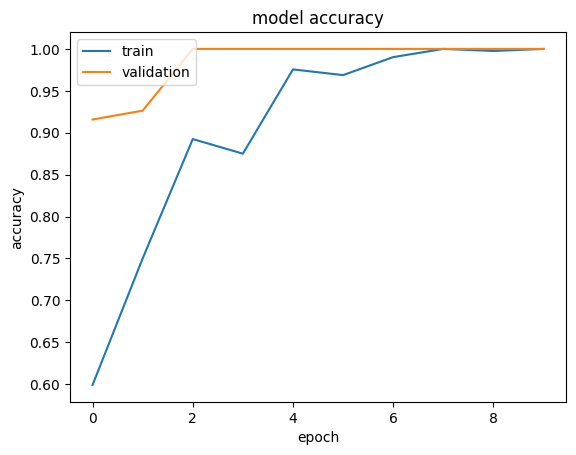

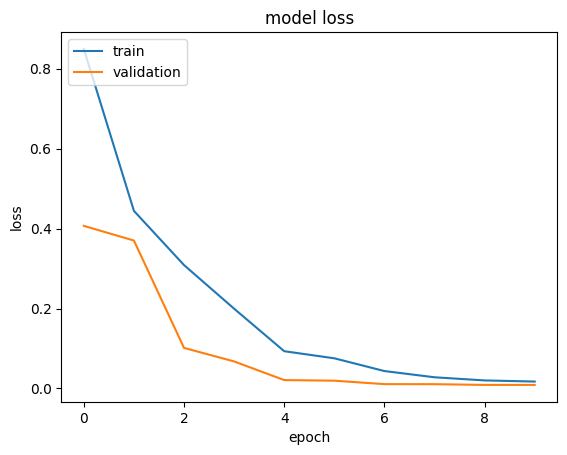

In [60]:
# accuracy plot
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# loss plot
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 106s 8s/step
train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
14/14 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step


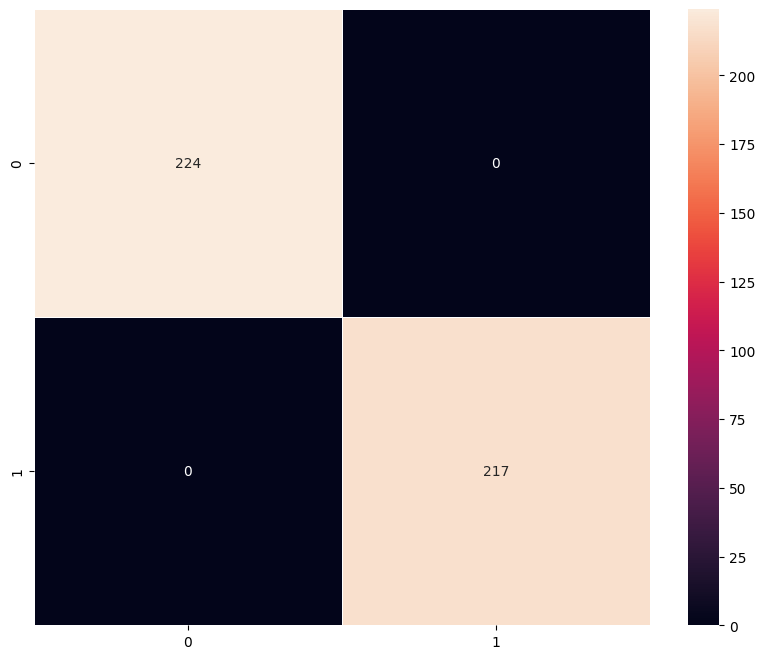

3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step
validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step


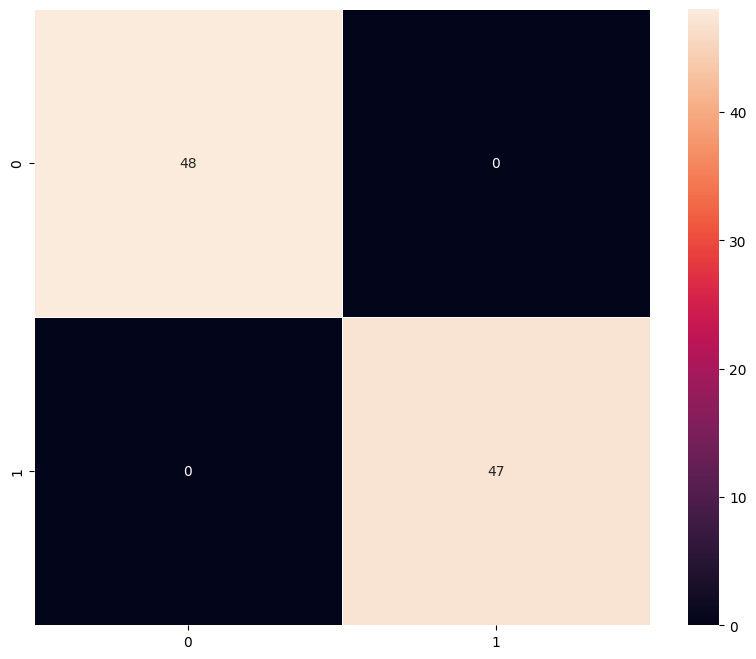

In [61]:
# training metrics
model_4_train_perf = model_performance_classification(model_4, X_train_normalized, y_train)
print("train performance metrics")
print(model_4_train_perf)

plot_confusion_matrix(model_4, X_train_normalized, y_train)

# validation metrics
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized, y_val)
print("validation performance metrics")
print(model_4_valid_perf)

plot_confusion_matrix(model_4, X_val_normalized, y_val)

#### Visualizing the predictions

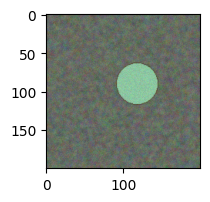

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
predicted label: 0
true label: label    0
Name: 561, dtype: int64


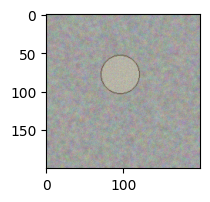

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
predicted label: 0
true label: label    0
Name: 20, dtype: int64


In [62]:
# prediction 1 - index 10
plt.figure(figsize=(2, 2))
plt.imshow(X_val[10])
plt.show()

pred = model_4.predict(X_val_normalized[10].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[10]

print('predicted label:', pred_label)
print('true label:', true_label)

# prediction 2 - index 30
plt.figure(figsize=(2, 2))
plt.imshow(X_val[30])
plt.show()

pred = model_4.predict(X_val_normalized[30].reshape(1, 200, 200, 3))
pred_label = 1 if pred[0][0] > 0.5 else 0
true_label = y_val.iloc[30]

print('predicted label:', pred_label)
print('true label:', true_label)

# Model Performance Comparison and Final Model Selection

In [63]:
# training performance comparison
models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)",
    "VGG-16 (Base)",
    "VGG-16 (Base+FFNN)",
    "VGG-16 (Base+FFNN+Data Aug)"
]

# validation performance comparison
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T,
    ],
    axis=1
)
models_valid_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)",
    "VGG-16 (Base)",
    "VGG-16 (Base+FFNN)",
    "VGG-16 (Base+FFNN+Data Aug)"
]

## Test Performance

Training Performance Comparison


,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.507937,1.0,1.0,1.0
Recall,0.507937,1.0,1.0,1.0
Precision,0.257999,1.0,1.0,1.0
F1 Score,0.342189,1.0,1.0,1.0


Validation Performance Comparison


,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.505263,1.0,1.0,1.0
Recall,0.505263,1.0,1.0,1.0
Precision,0.255291,1.0,1.0,1.0
F1 Score,0.339198,1.0,1.0,1.0


3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step
Test performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step


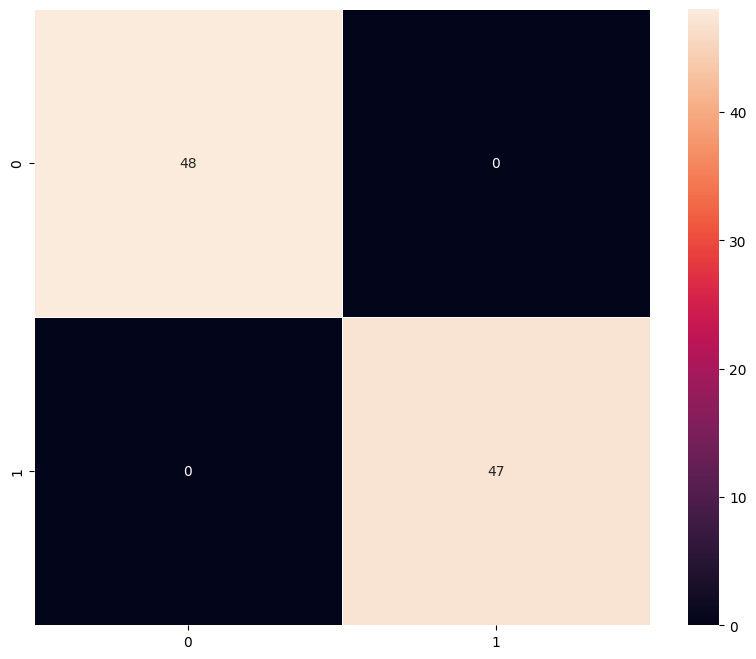

In [64]:
# Display comparison
print("Training Performance Comparison")
display(models_train_comp_df)
print("Validation Performance Comparison")
display(models_valid_comp_df)

# determine final model based on best validation performance
# if model_4 is best:
model_test_perf = model_performance_classification(model_4, X_test_normalized, y_test)
print("Test performance metrics")
print(model_test_perf)

# confusion matrix for test performance
plot_confusion_matrix(model_4, X_test_normalized, y_test)

Observations — Training/Validation Performance Comparison

| Model | Train Accuracy | Train Recall | Train Precision | Train F1 | Val Accuracy | Val Recall | Val Precision | Val F1 |
|---|---|---|---|---|---|---|---|---|
| Model 1: Simple CNN | 0.508 | 0.508 | 0.258 | 0.342 | 0.505 | 0.505 | 0.255 | 0.339 |
| Model 2: VGG16 (Base) | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 |
| Model 3: VGG16 (Base+FFNN) | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 |
| Model 4: VGG16 (Base+FFNN+Data Aug) | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 |

Model 1 (the simple CNN trained from scratch) collapses to predicting a single class, as detailed earlier. All three VGG16-based models (2, 3, and 4) reach perfect accuracy, recall, precision, and F1 on both training and validation data.

This gap illustrates the value of transfer learning on a small image dataset (441 training images): a CNN trained from scratch has too little data to learn useful visual features on its own, while VGG16's features — learned from 1.2 million ImageNet images — transfer well to distinguishing "with helmet" from "without helmet," even with a lightweight classification head and very few epochs.

# Actionable Insights & Recommendations

### Summary

Four models were evaluated: a simple CNN trained from scratch (Model 1), and three transfer-learning variants built on a frozen VGG16 base (Model 2: base + single dense layer; Model 3: base + a small feed-forward head; Model 4: base + feed-forward head + data augmentation).

**Model 1** failed to learn — its predictions collapsed to a single class (Accuracy ~51%, Recall/Precision/F1 ~0.00-0.34 for the "with helmet" class) due to an architecture bottleneck (an 80,000-unit `Flatten()` feeding into just 4 dense neurons), not due to a lack of learnable signal in the data.

**Models 2, 3, and 4** all reached perfect classification (Accuracy, Recall, Precision, F1 = 1.0) on both training and validation data, with Models 3 and 4 converging to that performance slightly faster and more smoothly than Model 2, likely due to their additional dense layers giving the classifier more capacity.

**Test set performance** for the selected best model (Model 4: VGG16 + FFNN + data augmentation) also reached perfect scores (Accuracy, Recall, Precision, F1 = 1.0), confirming the strong validation results hold on a fully held-out set.

**Recommendations:**
1. **Select Model 4** as the production model — it combines the strong VGG16 transfer-learning performance with data augmentation, which should make it more robust to real-world variation (lighting, angle, occlusion) than Models 2 or 3, even though all three scored identically on this dataset.
2. **Debug or replace Model 1's architecture** before using it as a baseline — the `Flatten()` → `Dense(4)` bottleneck should be replaced with a less aggressive reduction (e.g. `GlobalAveragePooling2D()` or a wider intermediate dense layer) if a from-scratch CNN is needed for comparison.
3. **Validate against a larger, more diverse test set** before deployment — perfect scores on a 95-image validation/test split are encouraging but should be confirmed against more images, ideally covering more real-world variation (different helmet colors, camera angles, lighting conditions, partial occlusion) than this dataset provides, to rule out the dataset being easier than real deployment conditions.
4. **Monitor for overfitting in production** — even though validation and test performance matches training performance closely here (no overfitting gap observed), that should be re-confirmed once real-world images are introduced, since perfect scores across the board can also indicate a task that's easier than the deployment setting will be.

Power Ahead!